# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Institut

- Nama: Kenny Calnelius Winata
- Email: jimhwang678@gmail.com
- Id Dicoding: jimhwang

## Persiapan

### Menyiapkan library yang dibutuhkan

In [395]:
import pandas as pd 
import os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from joblib import load 
import joblib
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Menyiapkan data yang akan diguankan

## Data Understanding

Membaca data seblum dilakukan pembersihan data

In [396]:
root = os.getcwd()
data_path = os.path.join(root, './data.csv')
df = pd.read_csv(data_path, sep=";")

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Mengecek ukuran jumlah baris dan kolom dari dataset

In [397]:
df.shape

(4424, 37)

Mengecek jumlah keunikan dari setiap kolom pada dataset

In [398]:
df.nunique()

Marital_status                                    6
Application_mode                                 18
Application_order                                 8
Course                                           17
Daytime_evening_attendance                        2
Previous_qualification                           17
Previous_qualification_grade                    101
Nacionality                                      21
Mothers_qualification                            29
Fathers_qualification                            34
Mothers_occupation                               32
Fathers_occupation                               46
Admission_grade                                 620
Displaced                                         2
Educational_special_needs                         2
Debtor                                            2
Tuition_fees_up_to_date                           2
Gender                                            2
Scholarship_holder                                2
Age_at_enrol

Mengecek informasi missing value maupun tipe data setiap kolom dataset

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

Mengecek jumlah missing value setiap kolom dataset

In [400]:
df.isna().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


Mengecek jumlah duplikasi yang ada pada dataset

In [401]:
# Check for duplicates
print(f"Jumlah Duplikasi Data: {df.duplicated().sum()}")

Jumlah Duplikasi Data: 0


Melihat gambaran statistik dari keseluruhan data

In [402]:
# Describe data 
df.describe(include='all')

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


## Exploratory Data Analysis

Meninjau jumlah masing-masing kategori pada kolom status

In [403]:
df["Status"].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

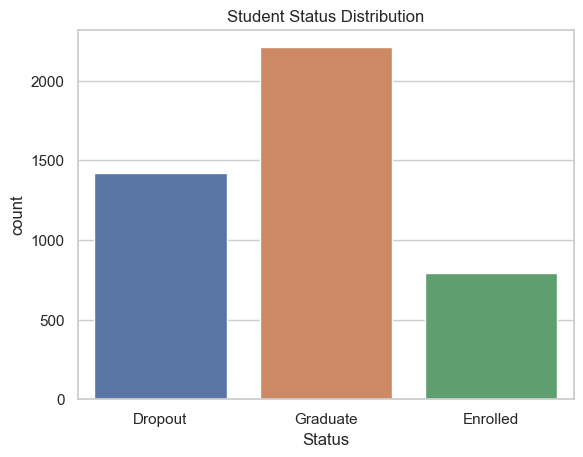

In [404]:
sns.countplot(x=df["Status"], hue=df["Status"])
plt.title("Student Status Distribution")
plt.show()

Dari visualisasi di atas, dapat diketahui bahwa Graduate status memiliki jumlah terbanyak diikuti oleh mahasiswa dengan status dropout dan Enrolled. Hal ini dapat menjadi peringatan bagi institut untuk lebih memperhatikan faktor-faktor yang menyebabkan sebagian mahasiswa yang dropout

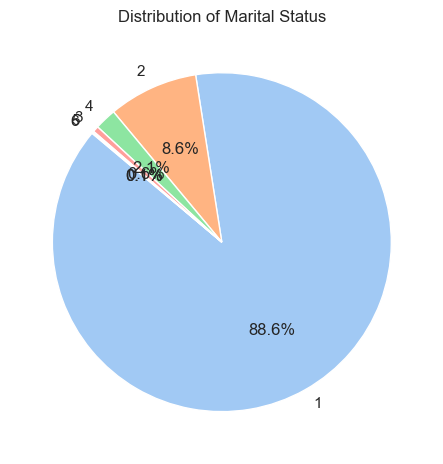

In [405]:
# Plot by Martial Status 
sns.set(style="whitegrid")
plt.pie(df['Marital_status'].value_counts(),
        labels=df['Marital_status'].unique(),
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette("pastel"))
plt.title('Distribution of Marital Status')
plt.tight_layout()
plt.show()

Dari distribusi status pernikahan di atas, mayoritas mahasiswa belum menikah, yaitu sekitar 88.6%

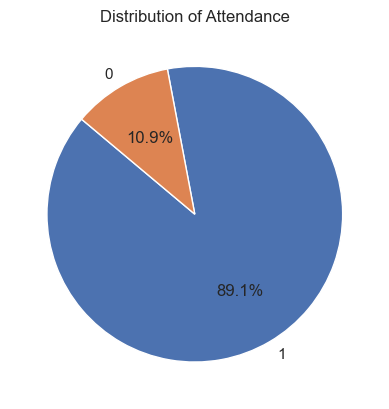

In [406]:

# Count by attendance in daytime or evening 
plt.pie(df['Daytime_evening_attendance'].value_counts(), labels=df['Daytime_evening_attendance'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Attendance')
plt.show()

Berdasarkan jumlah kehadiran, 89.1% mahasiswa berkuliah di sore hari, sedangkan sekitar 10.9% berkuliah di pagi hari

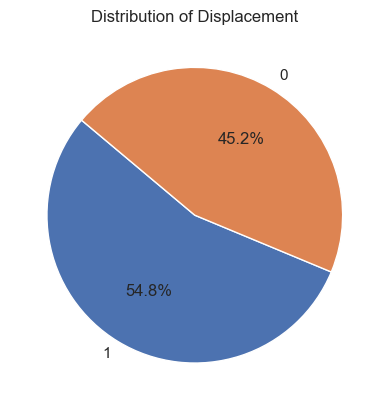

In [407]:
# Count by displacement 

plt.pie(df['Displaced'].value_counts(), labels=df['Displaced'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Displacement')
plt.show()

Berdasarkan grafik diatas, 54.8% mahasiswa merupakan mahasiswa pindahan

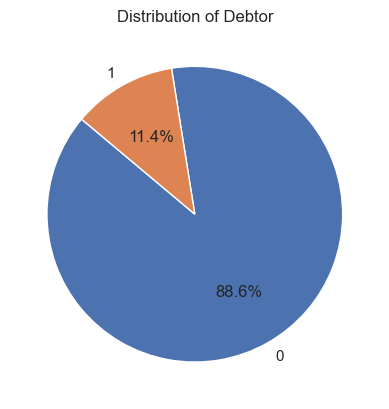

In [408]:
# Count by Debtor 
plt.pie(df['Debtor'].value_counts(), labels=df['Debtor'].unique(), autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Debtor')
plt.show()

Dari data diatas, 11.4% mahasiswa merupakan peminjam

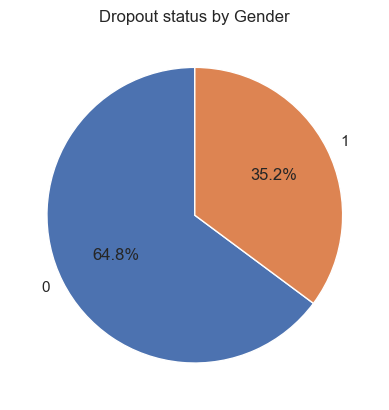

In [409]:
# Dropout status by gender 

plt.pie(x=df['Gender'].value_counts(), labels=df['Gender'].value_counts().index, autopct='%1.1f%%', startangle=90)  
plt.title('Dropout status by Gender')
plt.show()

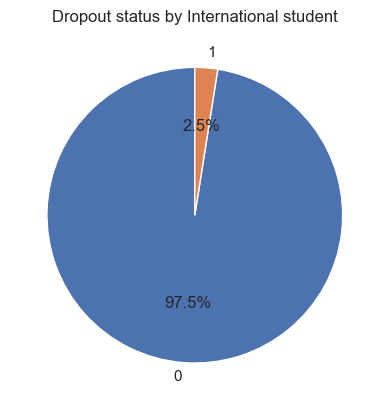

In [410]:
# Dropout status by International student
plt.pie(x=df['International'].value_counts(), labels=df['International'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Dropout status by International student')
plt.show()

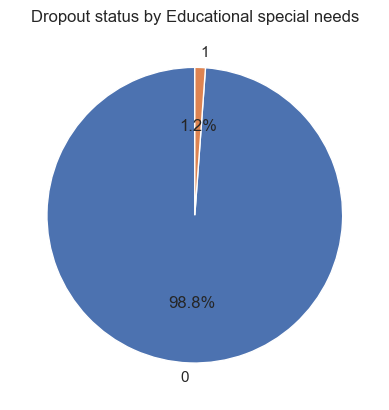

In [411]:
# Educational Special needs 
plt.pie(x=df['Educational_special_needs'].value_counts(), labels=df['Educational_special_needs'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Dropout status by Educational special needs')
plt.show()

Data diatas menunjukkan bahwa 1.2% mahasiswa yang dropout merupakan penerima bantuan khusus perkuliahan

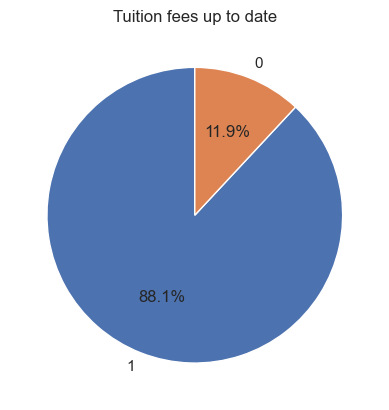

In [412]:
# Tution fees up to date

plt.pie(x=df['Tuition_fees_up_to_date'].value_counts(), labels=df['Tuition_fees_up_to_date'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Tuition fees up to date')
plt.show()

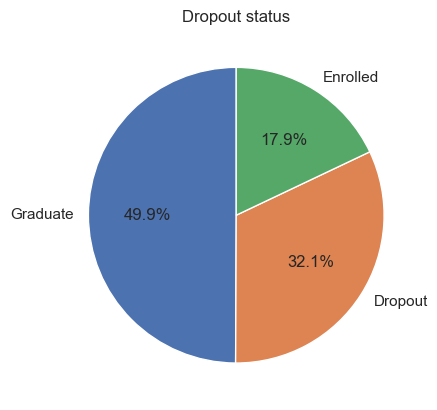

In [413]:
# Student Status ( Target )
plt.pie(x=df['Status'].value_counts(), labels=df['Status'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Dropout status')
plt.show()

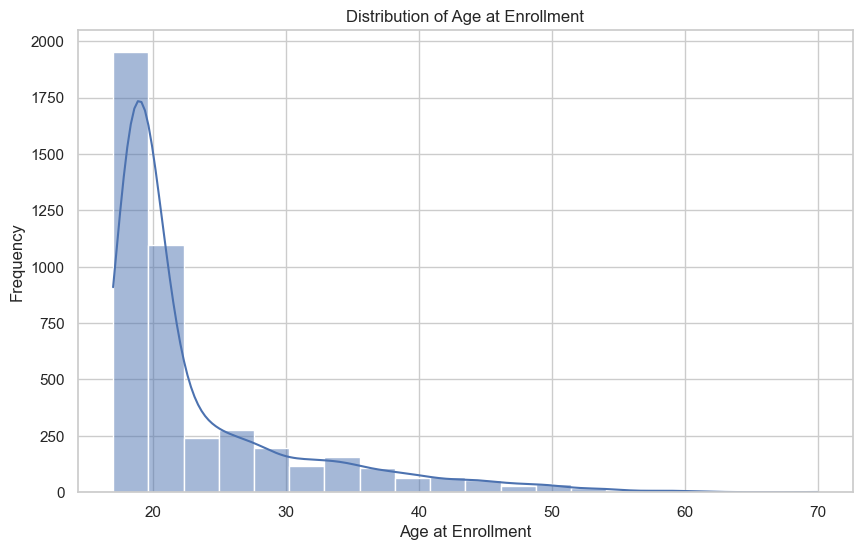

In [414]:
# Distribution of age at enrollment 

plt.figure(figsize=(10, 6))
sns.histplot(df['Age_at_enrollment'], bins=20, kde=True)
plt.title('Distribution of Age at Enrollment')
plt.xlabel('Age at Enrollment')
plt.ylabel('Frequency')
plt.show()

Distribusi Age At Enrollment cenderung right-skew, yang artinya lebih banyak mahasiswa yang berusia antara 18-22 yang melakukan enrollment

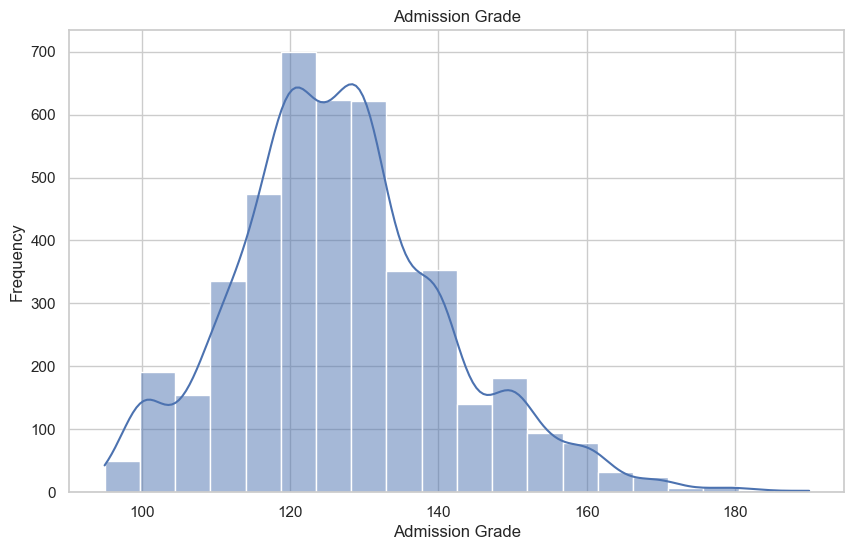

In [415]:
# Admission grade 
plt.figure(figsize=(10, 6))
sns.histplot(df['Admission_grade'], bins=20, kde=True)
plt.title('Admission Grade')
plt.xlabel('Admission Grade')
plt.ylabel('Frequency')
plt.show()

Distribusi dari admission grade cenderung normal/simetris

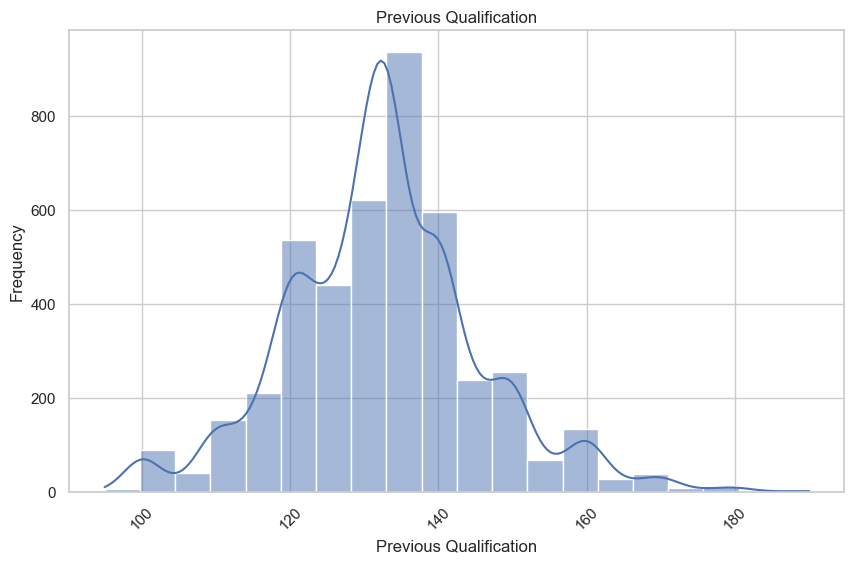

In [416]:
# Previous qualification
plt.figure(figsize=(10, 6))
sns.histplot(df['Previous_qualification_grade'], bins=20, kde=True)
plt.title('Previous Qualification')
plt.xlabel('Previous Qualification')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

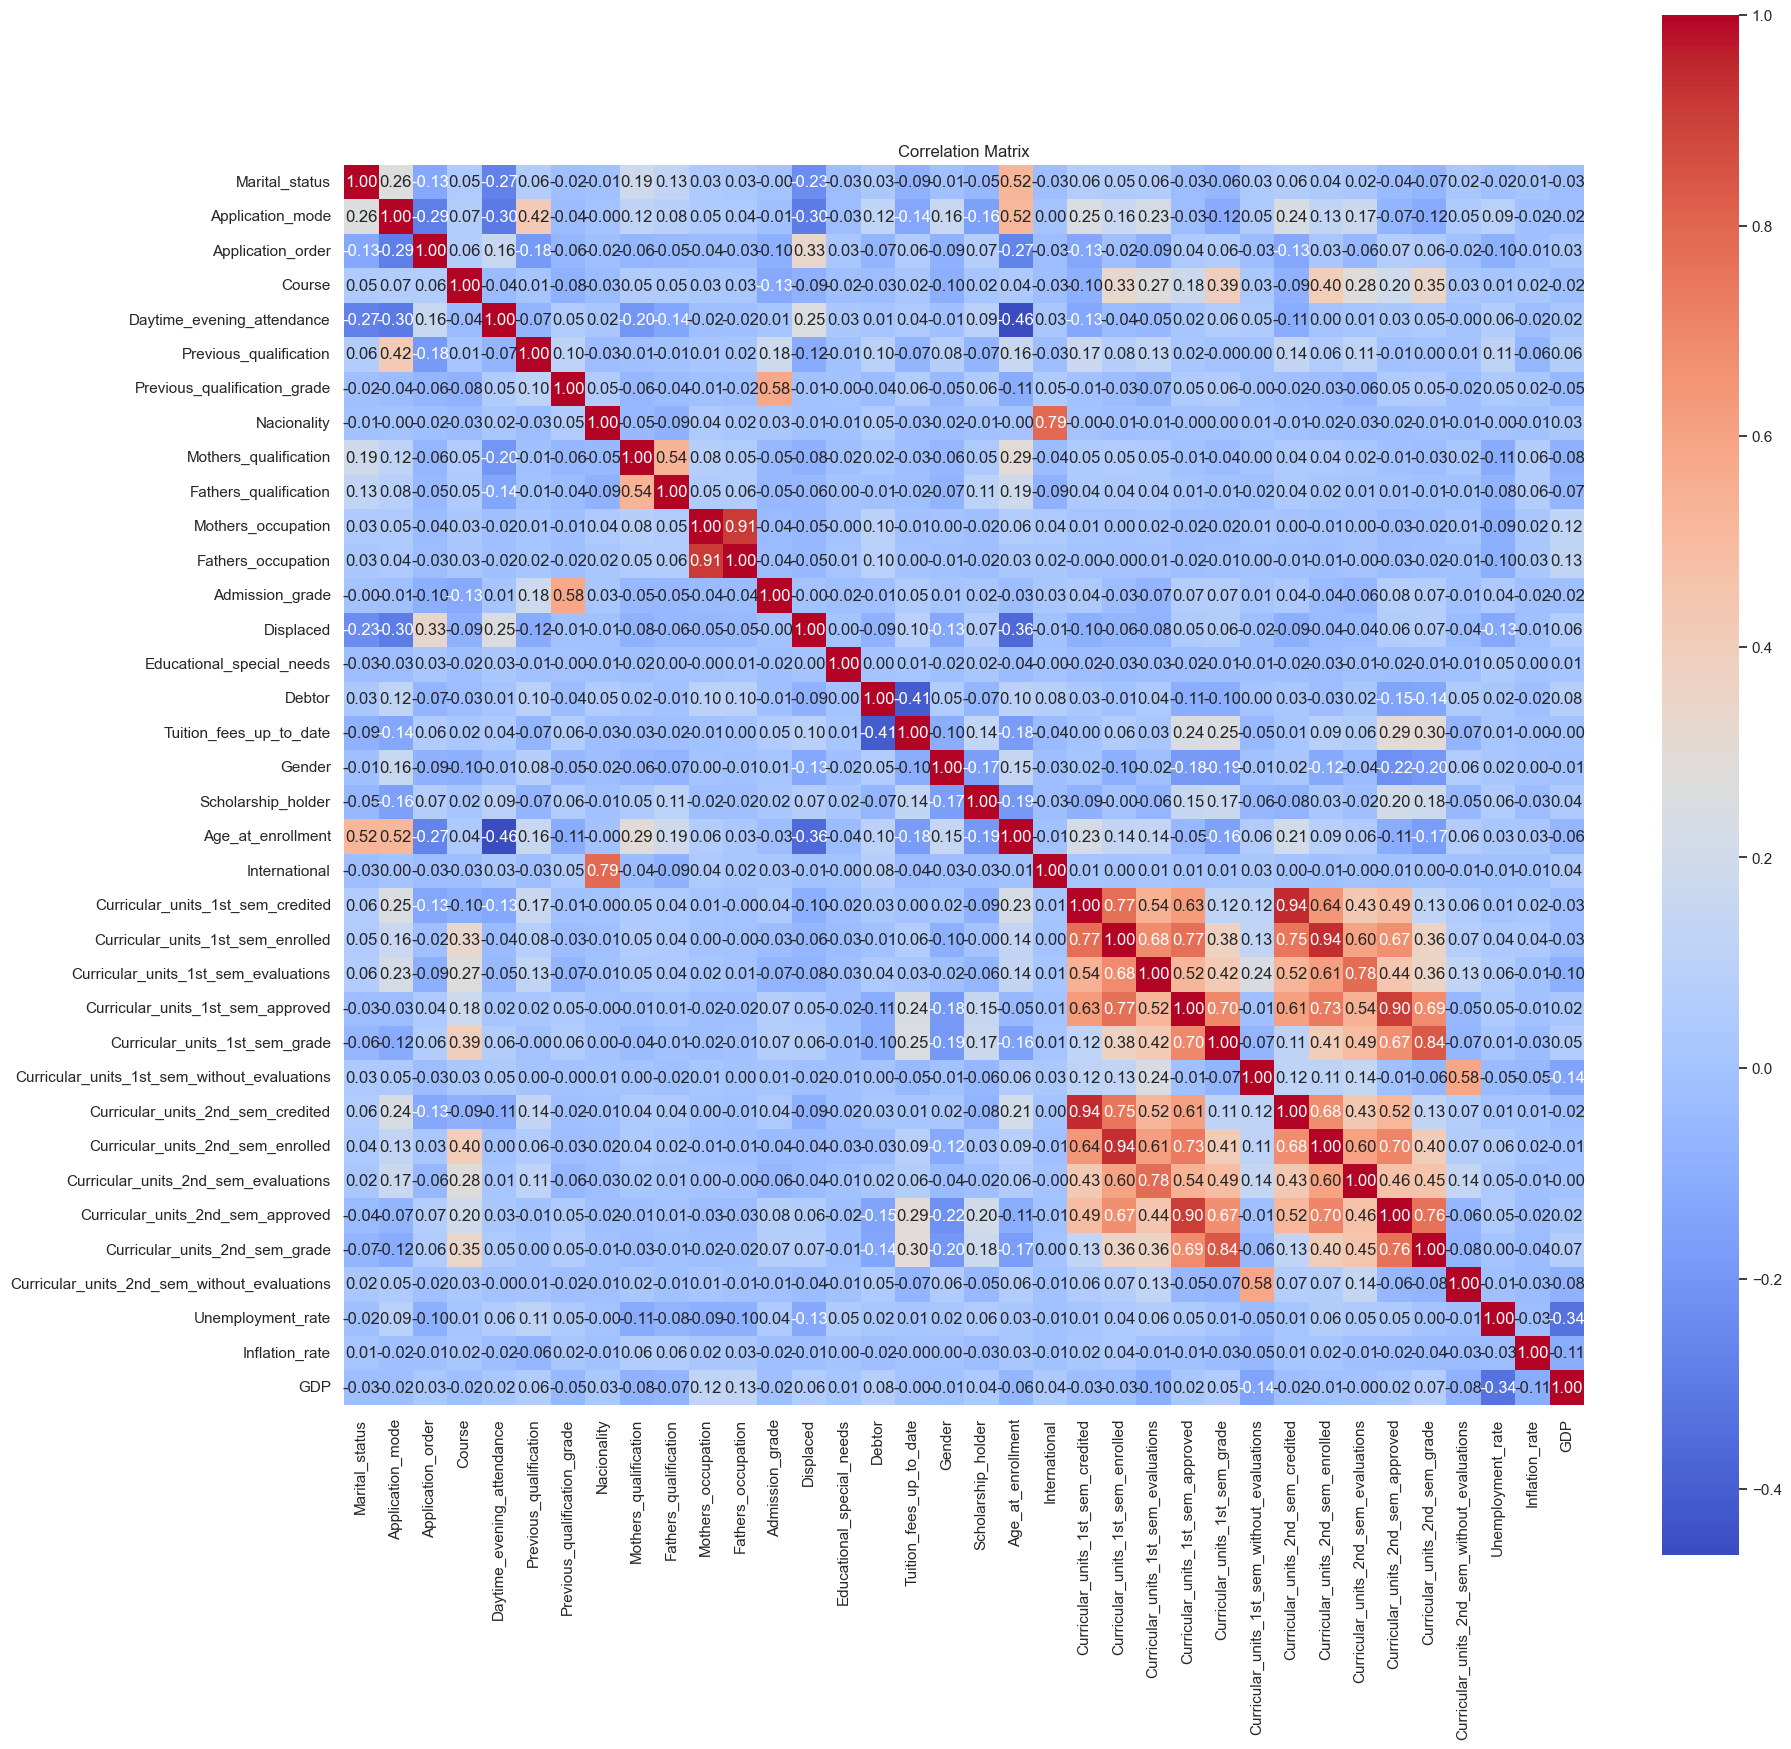

In [417]:
# Checking correlation between features
plt.figure(figsize=(20, 20))

df_copy = df.drop(columns='Status')

sns.heatmap(df_copy.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

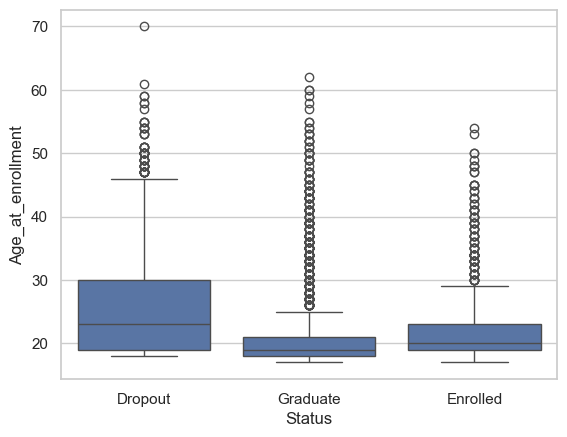

In [418]:
sns.boxplot(
    x="Status",
    y="Age_at_enrollment",
    data=df
)

plt.show()

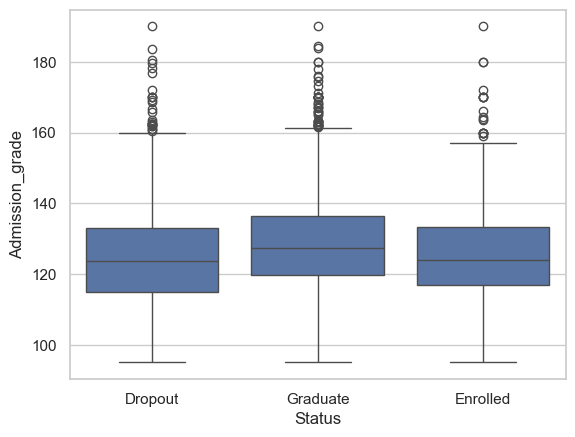

In [419]:
sns.boxplot(
    x="Status",
    y="Admission_grade",
    data=df
)

plt.show()

## Data Preparation / Preprocessing

In [420]:
# Check for missing values 
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [421]:
# Check for duplicate values 
df.duplicated().sum()

np.int64(0)

In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

Pengubahan status kategorikal menjadi numerikal dengan mengubah status enroll dan graduate sebagai 0, dan dropout sebagai 1

In [423]:
df["Status"] = df["Status"].apply(
    lambda x: 1 if x=="Dropout" else 0
)

In [424]:
# Convert categorical variables to numerical
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
label_encoder = LabelEncoder()

df['Status'] = label_encoder.fit_transform(df['Status'])
X = df.drop("Status",axis=1)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
y = df["Status"]
print(len(X.columns))
print(X.columns.tolist())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

36
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP']


## Modeling

Melakukan modeling dengan beberapa algoritma Machine Learning, yaitu dengan membandingkan algoritma Logistic Regression, Random Forest dan XGBoost, lalu pilih yang terbaik untuk disimpan modelnya

In [425]:
# Use Logistic Regression as baseline model
log_reg = LogisticRegression(max_iter=500)

# Using Other Models - Random Forest 
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42, max_depth=100)

# Using Other Models - XGBoost
svc = SVC(kernel='linear', random_state=42)

## Evaluation

Evaluasi masing-masing algoritma dengan visualisasi confusion matrix

Logistic Regression Accuracy: 0.8666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90       569
           1       0.88      0.72      0.79       316

    accuracy                           0.87       885
   macro avg       0.87      0.83      0.85       885
weighted avg       0.87      0.87      0.86       885



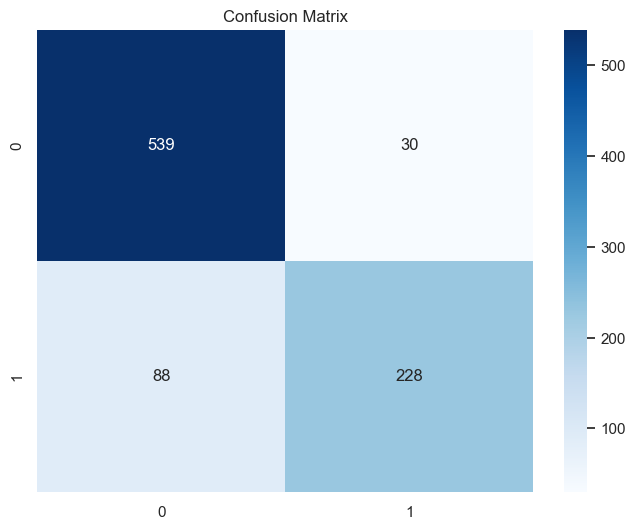

In [426]:
# # Evaluate the Logistic Regression Model
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.show()

Random Forest Accuracy: 0.8621468926553673
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90       569
           1       0.88      0.71      0.79       316

    accuracy                           0.86       885
   macro avg       0.87      0.83      0.84       885
weighted avg       0.86      0.86      0.86       885



Text(0.5, 1.0, 'Confusion Matrix - Random Forest')

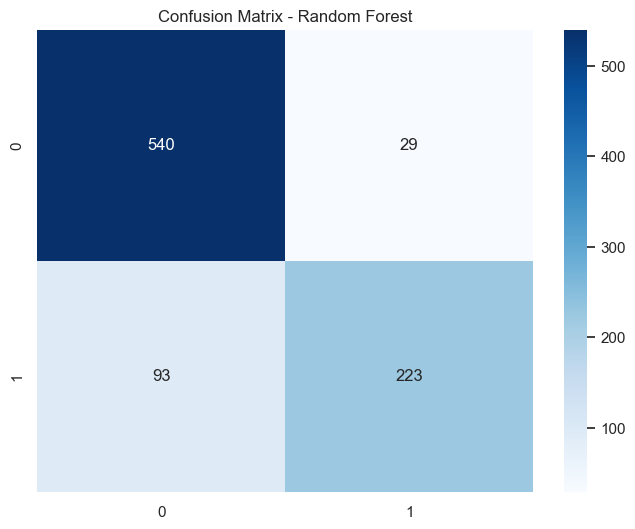

In [427]:
# Evaluate the Random Forest model
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest')

SVC Accuracy: 0.8519774011299435
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89       569
           1       0.89      0.67      0.76       316

    accuracy                           0.85       885
   macro avg       0.86      0.81      0.83       885
weighted avg       0.86      0.85      0.85       885



Text(0.5, 1.0, 'Confusion Matrix - SVC')

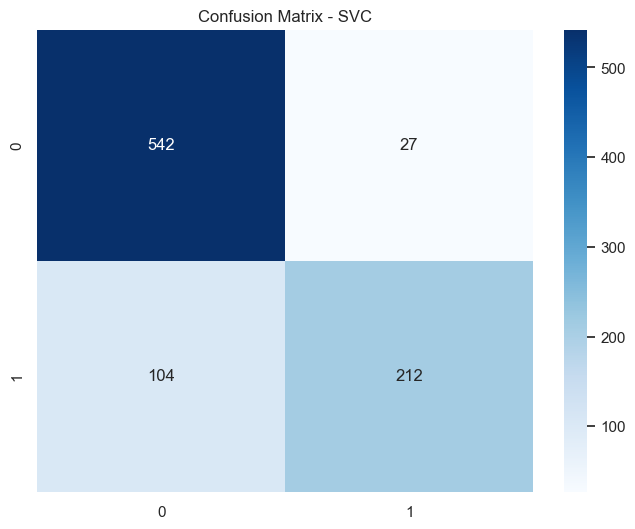

In [428]:
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# Evaluate the SVC model
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_svc))
# Confusion Matrix for SVC
cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - SVC')

In [429]:
# Use pd Dataframe for checking the accuracy of the models
from sklearn.metrics import f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVC'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_svc)],
    'F1 Score': [f1_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted'), f1_score(y_test, y_pred_svc, average='weighted'), ],
})
results = results.sort_values(by='Accuracy', ascending=False)
results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.866667,0.863163
1,Random Forest,0.862147,0.858050
2,SVC,0.851977,0.846400


In [430]:
importance = rf_model.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    "feature":features,
    "importance":importance
})

imp_df = imp_df.sort_values(
    "importance",
    ascending=False
)

imp_df.head(10)

,feature,importance
30,Curricular_units_2nd_sem_approved,0.159430
31,Curricular_units_2nd_sem_grade,0.123312
24,Curricular_units_1st_sem_approved,0.088925
25,Curricular_units_1st_sem_grade,0.069937
16,Tuition_fees_up_to_date,0.066243
19,Age_at_enrollment,0.040166
29,Curricular_units_2nd_sem_evaluations,0.038007
12,Admission_grade,0.036201
6,Previous_qualification_grade,0.032890
3,Course,0.031995


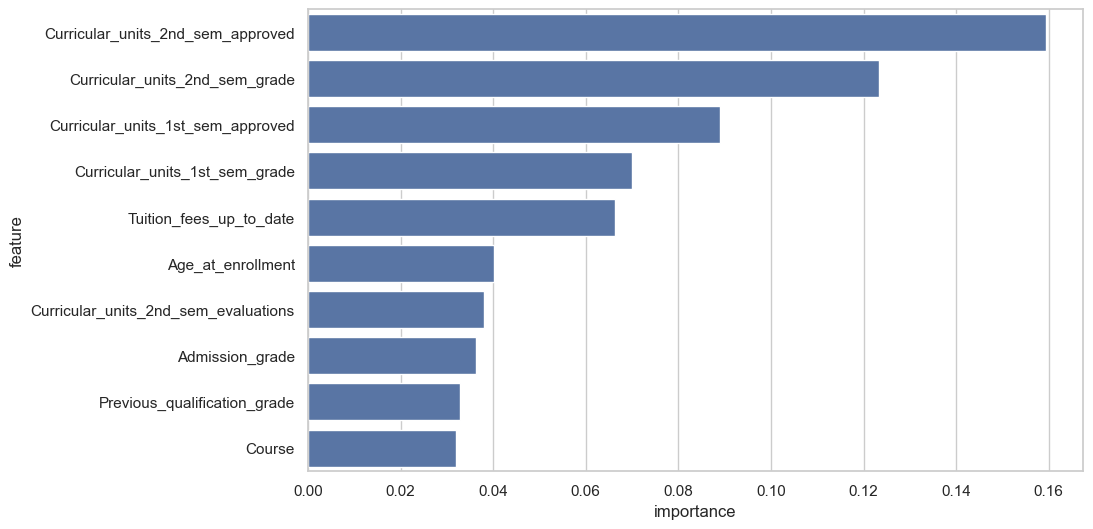

In [431]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=imp_df.head(10)
)

plt.show()

## Insight Analisis

Key Insights dari Analisis Data Mahasiswa Jaya Jaya Institut

Berdasarkan hasil exploratory data analysis (EDA), feature importance analysis, serta hasil pemodelan machine learning menggunakan Logistic Regression, diperoleh beberapa insight penting terkait faktor-faktor yang mempengaruhi kemungkinan mahasiswa mengalami dropout.

1. Performa akademik semester awal menjadi indikator terkuat dropout

    Hasil analisis menunjukkan bahwa jumlah mata kuliah yang lulus (approved units) serta nilai akademik pada semester pertama dan kedua merupakan indikator paling kuat dalam menentukan apakah mahasiswa akan dropout atau tidak. Mahasiswa dengan jumlah mata kuliah lulus yang rendah memiliki probabilitas dropout yang jauh lebih tinggi dibanding mahasiswa dengan performa akademik yang stabil.

    Insight ini menunjukkan bahwa performa akademik pada tahun pertama merupakan fase kritis yang dapat digunakan sebagai indikator early warning untuk risiko dropout.

2. Mahasiswa dengan masalah finansial memiliki risiko dropout lebih tinggi

    Mahasiswa yang memiliki status keterlambatan pembayaran biaya kuliah (tuition fees not up to date) atau memiliki status debtor cenderung memiliki kemungkinan dropout yang lebih tinggi. Hal ini menunjukkan bahwa faktor ekonomi masih menjadi salah satu penyebab utama mahasiswa tidak menyelesaikan pendidikan.

    Insight ini menunjukkan pentingnya kebijakan dukungan finansial sebagai strategi retensi mahasiswa.

3. Penerima beasiswa cenderung memiliki tingkat keberhasilan studi lebih tinggi

    Mahasiswa yang menerima beasiswa (scholarship holder) secara umum memiliki tingkat dropout yang lebih rendah. Hal ini dapat disebabkan oleh adanya dukungan finansial serta kemungkinan adanya proses seleksi yang memastikan mahasiswa penerima beasiswa memiliki kesiapan akademik yang baik.

    Insight ini menunjukkan bahwa program beasiswa tidak hanya membantu akses pendidikan tetapi juga meningkatkan student retention.

4. Usia saat masuk kuliah memiliki pengaruh terhadap keberhasilan studi

    Mahasiswa dengan usia masuk yang lebih tinggi dibanding rata-rata menunjukkan kecenderungan risiko dropout yang sedikit lebih tinggi. Hal ini kemungkinan berkaitan dengan tanggung jawab tambahan di luar akademik seperti pekerjaan atau faktor keluarga.

    Insight ini menunjukkan bahwa mahasiswa non-traditional age mungkin membutuhkan pendekatan akademik yang lebih fleksibel.

5. Model Logistic Regression efektif untuk prediksi risiko dropout

    Dari beberapa model yang diuji, Logistic Regression memberikan performa terbaik dengan keseimbangan antara accuracy dan recall yang baik. Selain itu, model ini juga memberikan interpretasi yang jelas terhadap pengaruh masing-masing variabel terhadap risiko dropout.

    Insight ini menunjukkan bahwa model yang sederhana namun interpretable dapat menjadi solusi yang efektif untuk implementasi nyata di institusi pendidikan.

6. Kombinasi faktor akademik dan non-akademik menentukan risiko dropout

    Analisis menunjukkan bahwa dropout tidak hanya dipengaruhi oleh satu faktor tunggal, tetapi merupakan kombinasi dari performa akademik, kondisi finansial, serta karakteristik mahasiswa. Hal ini menunjukkan bahwa pendekatan intervensi juga harus bersifat multidimensional, tidak hanya fokus pada akademik saja.

## Save Model

In [433]:
# feature_names = X.columns

# joblib.dump(feature_names,"features.joblib")

joblib.dump(log_reg,"model.joblib")

joblib.dump(scaler,"scaler.joblib")

['scaler.joblib']